In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath("../"))

In [2]:
import photospline

from icecube import dataio, icetray, dataclasses, simclasses, gulliver
import numpy.random as random
import numpy as np
import scipy.optimize as optimize
import matplotlib.pyplot as plt
from scripts.python.SplineEval import evalLogPdf, evalPdf
from matplotlib.colors import LogNorm

In [3]:
import pandas as pd
pd.set_option('display.max_rows', 20)

In [4]:
df = pd.read_csv('../scripts/python/tracking.csv')
standard_dev = np.std(df['pdf contribution'])
mean = np.mean(df['pdf contribution'])

mask = df['pdf contribution'] < 1
df_outliers = df[mask]

In [5]:
mean

4.930091474926254

In [6]:
len(df['pdf contribution'])

339

In [7]:
df_outliers['pdf contribution']

Series([], Name: pdf contribution, dtype: float64)

In [9]:
all_dr = df['dr']
all_dphi = df['dphi']
all_Ephi = df['Ephi']
all_tres = df['tres']
out_dr = df_outliers['dr']
out_dphi = df_outliers['dphi']
out_Ephi = df_outliers['Ephi']
out_tres = df_outliers['tres']

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.hist(all_dr, np.linspace(min(all_dr), max(all_dr), 100))
ax1.set_title("All dr distribution")
ax1.set_xlabel('dr (m)')
ax2.hist(out_dr, np.linspace(min(all_dr), max(all_dr), 100))
# ax2.set_title(f'5$\sigma$ dr distribution')
ax2.set_title(f'-llh < 2 dist')

ax2.set_xlabel('dr (m)')
fig.tight_layout()
fig.savefig('/mnt/home/dillonb5/cascades/plots/dr_most_likely.png')

KeyError: 'dphi'

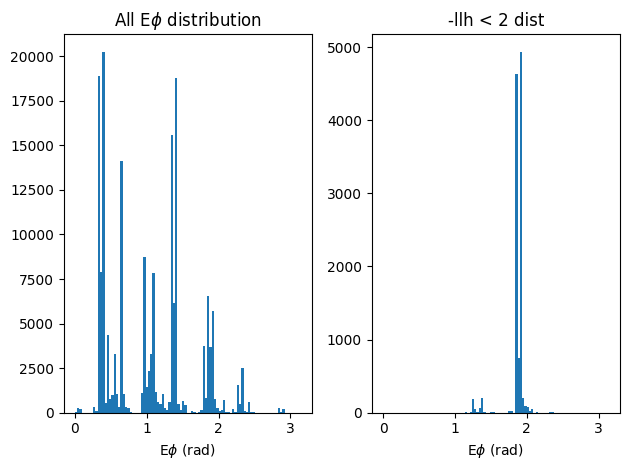

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.hist(all_Ephi, np.linspace(0, np.pi, 100))
ax1.set_title(f"All E$\phi$ distribution")
ax1.set_xlabel(f'E$\phi$ (rad)')
ax2.hist(out_Ephi, np.linspace(0, np.pi, 100))
#ax2.set_title(f'5$\sigma$ E$\phi$ distribution')
ax2.set_title(f'-llh < 2 dist')
ax2.set_xlabel(f'E$\phi$ (rad)')
fig.tight_layout()
fig.savefig('/mnt/home/dillonb5/cascades/plots/Ephi_most_likely.png')

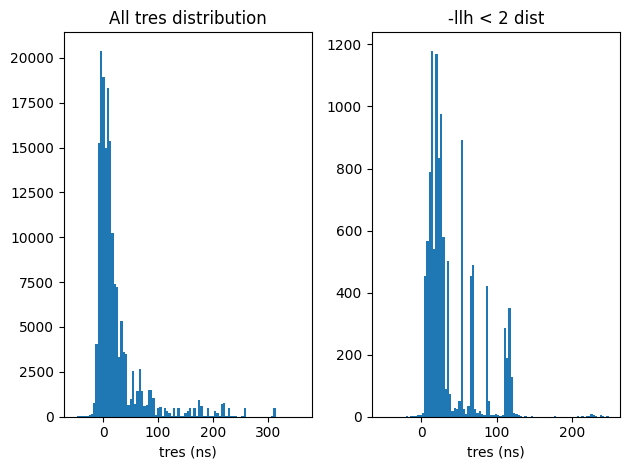

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.hist(all_tres, np.linspace(min(all_tres), max(all_tres), 100))
ax1.set_title("All tres distribution")
ax1.set_xlabel('tres (ns)')
ax2.hist(out_tres, np.linspace(min(all_tres), max(out_tres), 100))
# ax2.set_title(f'5$\sigma$ tres distribution')
ax2.set_title(f'-llh < 2 dist')

ax2.set_xlabel('tres (ns)')
fig.tight_layout()
#ax2.vlines(0, 0, 40, colors = 'red', ls = '--')
fig.savefig('/mnt/home/dillonb5/cascades/plots/tres_most_likely.png')

In [ ]:
bad_mask = df['tres'] < 0
df[bad_mask]

,pdf contribution,dr,Ephi,tres,eX,eY,eZ,eT,eZenith,eAzimuth
200,9.76736,59.0715,0.401272,-8.385060,-475.123,-347.197,-170.989,0.00000,2.10793,6.06428
201,7.36901,59.0715,0.401272,-5.014130,-475.123,-347.197,-170.989,0.00000,2.10793,6.06428
202,5.32010,59.0715,0.401272,-2.947220,-475.123,-347.197,-170.989,0.00000,2.10793,6.06428
203,5.13631,59.0715,0.401272,-2.714940,-475.123,-347.197,-170.989,0.00000,2.10793,6.06428
204,5.08044,59.0715,0.401272,-2.642540,-475.123,-347.197,-170.989,0.00000,2.10793,6.06428
...,...,...,...,...,...,...,...,...,...,...
219539,3.54163,59.0295,0.345468,-1.404390,-475.011,-347.095,-170.786,-0.88648,1.99965,6.03097
219540,3.44676,59.0295,0.345468,-1.232370,-475.011,-347.095,-170.786,-0.88648,1.99965,6.03097
219541,3.38383,59.0295,0.345468,-1.113710,-475.011,-347.095,-170.786,-0.88648,1.99965,6.03097
219542,3.37251,59.0295,0.345468,-1.091990,-475.011,-347.095,-170.786,-0.88648,1.99965,6.03097


In [8]:
file_500 = dataio.I3File('../nue_data/gen_500.i3.zst')
file_012 = dataio.I3File('../nue_data/gen_012.i3.zst')
file_015 = dataio.I3File('/mnt/scratch/dillonb5/sampled_data_byhand/new_015.i3.zst')
file_80 = dataio.I3File('/mnt/scratch/dillonb5/const_tres/new_080.i3.zst')

gcd = dataio.I3File('../gcdfile/PONE_800mGrid.i3.gz')

iter = 0
for frame in file_500:
    if iter == 17:
        frame18 = frame
    if iter == 26:
        frame27 = frame

    if iter == 92:
        frame93 = frame
    if iter == 127:
        frame128 = frame
    
    iter += 1
iter = 0
for frame in file_012:
    if iter == 69:
        frame70 = frame
    iter += 1

iter = 1
for frame in file_015:
    if iter == 40:
        frame40 = frame
    elif iter == 51:
        frame51 = frame
    iter += 1

iter = 1
for frame in file_80:
    if iter==22:
        frame80 = frame
    iter += 1
for frame in gcd:
    gcdframe = frame
    break

In [19]:
print((frame80['I3MCTree'][2]).minor_id)

807


In [67]:
print(frame80['I3MCTree'][1])

[ I3Particle MajorID : 16677733219058608167
             MinorID : 804
              Zenith : 2.10793
             Azimuth : 6.06428
                   X : -475.123
                   Y : -347.197
                   Z : -170.989
                Time : 0
              Energy : 114.142
               Speed : 0.299792
              Length : nan
                Type : EMinus
        PDG encoding : 11
               Shape : Cascade
              Status : NotSet
            Location : InIce
]


In [12]:
(frame80['LLHFit_step5FitParams'].logl)

KeyError: 'LLHFit_step5FitParams'

In [ ]:
frame80['LLHFit_mctruth'].logl

KeyError: 'LLHFit_mctruth'

In [ ]:
len(frame80['I3Photons'])

27

In [ ]:
splinefit_3d = photospline.SplineTable('../fits/splinelog_3D.fits')

In [ ]:
print(splinefit_3d.extents[2][0], splinefit_3d.extents[2][1])

-30.726762008826114 1627.6756954685331


In [ ]:
print(min(splinefit_3d.knots[-1]), max(splinefit_3d.knots[-1]))

-52.90817161588701 2322.11625869322


In [13]:
# Randomly chosen set of strings. I just ran the random sampler until it looked nice. Feel free to make a more intelligent 
# subselection for future studies
string_subset = np.array([266, 199, 220, 275,  96, 113, 112, 286, 173, 116, 8, 240, 130,
       307, 281, 112, 324, 306, 183, 303, 314, 289,  72, 113, 147, 177,
       160,  57,  54, 142, 291, 204,  75, 215, 179, 143, 315, 201, 182,
        78,  60,   1, 326,  46, 272, 232, 134, 162, 268, 101, 139, 320,
       195,  11,  86, 300,  84,  67, 129,  63, 310,  59, 215, 312, 188,
       138,  71, 120, 139,  12,  26, 117, 129,  40,   6, 156,  79, 132,
       127, 161])

In [45]:
for p in frame80['I3Photons']:
    print(p[1][0].groupVelocity)
    break

0.21880510449409485


In [ ]:
c = 299792458
n = 1.34


def datacollect(frame):
    dt = []
    t = []
    dphilst = []
    dr = []
    xyz = []
    v = []

    Epos = frame["I3MCTree"][1].pos
    doms = gcdframe["I3ModuleGeoMap"]
    omkeys = frame["new_photons"].keys()
    photons = frame["new_photons"]
    for key in omkeys:
        # Un-comment if you want to use only a string subset
        # if key.string not in string_subset:
        #     continue
        modulekey = dataclasses.ModuleKey(key.string, key.om)
        dompos = doms[modulekey].pos
        for photon in photons[key]:
            photon_pos = dompos
            xyz.append([photon_pos.x, photon_pos.y, photon_pos.z])
            flight = dompos + photon.pos - Epos
            dr.append(flight.magnitude)
            offset = flight.magnitude * n / c
            dt.append(photon.time - offset * 10**9)
            t.append(photon.time)
            phi = photon.dir
            randx, randy, randz = random.uniform(-1, 1, 3)
            x = phi.x
            y = phi.y
            z = phi.z
            dx = x - randx
            dy = y - randy
            dz = z - randz
            dphi = dataclasses.I3Direction(dx, dy, dz)
            dphilst.append(dphi.zenith)
            # Etheta.append(flight.azimuth)
            # Ephi.append(flight.zenith)
            

    return np.column_stack([xyz, t, dt])

In [73]:
# EventData1 = datacollect(frame18)
# EventData2 = datacollect(frame27)
# EventData3 = datacollect(frame70)
# EventData4 = datacollect(frame93)
# EventData5 = datacollect(frame128)
#EventData6 = datacollect(frame40)
#EventData7 = datacollect(frame51)
EventDataLLHFit = datacollect(frame80)

In [26]:
EventDataLLHFit[:,-1]

array([ 3.68934881e+19,  3.68934881e+19,  3.68934881e+19,  3.68934881e+19,
        0.00000000e+00,  3.68934881e+19, -1.08420217e-19,  1.08420217e-19,
        3.68934881e+19,  3.68934881e+19,  0.00000000e+00,  3.68934881e+19,
        3.68934881e+19,  3.68934881e+19,  3.68934881e+19,  3.68934881e+19,
        3.68934881e+19,  3.68934881e+19, -1.08420217e-19,  3.68934881e+19,
        3.68934881e+19, -0.00000000e+00,  3.68934881e+19, -1.08420217e-19,
        3.68934881e+19,  3.68934881e+19,  3.68934881e+19,  3.68934881e+19,
        3.68934881e+19,  1.08420217e-19,  1.08420217e-19,  3.68934881e+19,
        3.68934881e+19,  3.68934881e+19,  3.68934881e+19,  3.68934881e+19,
        3.68934881e+19,  3.68934881e+19,  0.00000000e+00,  3.68934881e+19,
       -3.68934881e+19,  0.00000000e+00, -3.68934881e+19, -3.68934881e+19,
        0.00000000e+00, -3.68934881e+19,  3.68934881e+19,  3.68934881e+19,
       -3.68934881e+19,  3.68934881e+19, -3.68934881e+19,  3.68934881e+19,
       -3.68934881e+19,  

In [17]:
def displacement_magnitude(pos1: np.array, pos2: np.array) -> float:
    vector = pos1 - pos2
    return np.sqrt(vector[0] ** 2 + vector[1] ** 2 + vector[2] ** 2)

In [48]:
def Likelihood_3d(coords: np.array, Event: np.array):
    L = 0
    # coords should have shape [x,y,z,theta,phi,t]
    # Event has shape [N, 6] cols:(x,y,z,t,dr,dt). We only use the first 4 here

    event_xyz = Event[:, 0:3]
    event_t = Event[:, 3]

    # Calculate Displacement Magnitude
    diff = coords[0:3] - event_xyz
    dr = np.linalg.norm(diff, axis=1)
    # Calculate Time Residual
    dt = event_t - coords[5] - (1.34*dr/c * 1e9)
    # dt = event_t

    # Construct Electron direction unit vector from zenith and azimuth
    Ex = np.sin(coords[4]) * np.cos(coords[3])
    Ey = np.sin(coords[4]) * np.sin(coords[3])
    Ez = np.cos(coords[4])

    # Calculate angle between electron travel vector and displacement vector
    Eangle = np.array([Ex, Ey, Ez])
    Ephi = np.arccos(np.dot(diff, Eangle) / dr)

    # print(Ephi)
    # Calculate Likelihood from constructed coordinates
    params = np.array([dr, Ephi, dt])
    vals = splinefit_3d.evaluate_simple([params[0], params[1], params[2]])
    L = np.where(vals == 0, -30, vals)
    return -np.sum(L)

In [74]:
def find_tres(coords, Event):
    tres_list = []
    event_xyz = Event[:, 0:3]
    event_t = Event[:, 3]

    # Calculate Displacement Magnitude
    diff = coords[0:3] - event_xyz
    dr = np.linalg.norm(diff, axis=1)
    # Calculate Time Residual
    dt = (event_t - coords[5]) - (1.34*dr / dataclasses.I3Constants.c)
    tres_list.append(dt)
    return(dt)

In [ ]:
for p in frame80['I3Photons']:
    print((p[1][0].GetGroupVelocity()))
    break

0.21880510449409485


In [50]:
print(frame80['I3MCTree'][1])

[ I3Particle MajorID : 16677733219058608167
             MinorID : 804
              Zenith : 2.10793
             Azimuth : 6.06428
                   X : -475.123
                   Y : -347.197
                   Z : -170.989
                Time : 0
              Energy : 114.142
               Speed : 0.299792
              Length : nan
                Type : EMinus
        PDG encoding : 11
               Shape : Cascade
              Status : NotSet
            Location : InIce
]


In [75]:
tres_lst = find_tres(np.array([-475.123, -347.197, -170.989, 6.06428, 2.10793, 0]), EventDataLLHFit)

In [77]:
tres_lst

array([ 9.99980966,  9.99973604,  9.99940657,  9.99911722,  9.99911722,
        9.99911722,  9.99911722,  9.99911722,  9.99911722,  9.9989563 ,
        9.9989563 ,  9.9989563 ,  9.9989563 ,  9.9989563 ,  9.9989563 ,
        9.9989563 ,  9.9989563 ,  9.9989563 ,  9.9989563 ,  9.9989563 ,
        9.9989563 ,  9.9989563 ,  9.9989563 ,  9.9989563 ,  9.9989563 ,
        9.9989563 ,  9.9989563 ,  9.9989563 ,  9.9989563 ,  9.9989563 ,
        9.9989563 ,  9.9989563 ,  9.9989563 ,  9.9989563 ,  9.9989563 ,
        9.9989563 ,  9.9989563 ,  9.99903541,  9.99903541,  9.99917302,
       10.00033243, 10.00033243, 10.00033243, 10.0003299 , 10.0003299 ,
       10.0003299 , 10.0003299 , 10.0003299 , 10.0003299 , 10.0003299 ,
       10.0003299 , 10.0003299 , 10.0003299 , 10.0003299 , 10.0003299 ,
       10.0003299 , 10.0003299 , 10.0003299 , 10.0003299 , 10.0003299 ,
       10.0003299 , 10.0003299 , 10.0003299 , 10.0003299 , 10.0003299 ,
       10.0003299 , 10.0003299 , 10.00005085, 10.00005085, 10.00

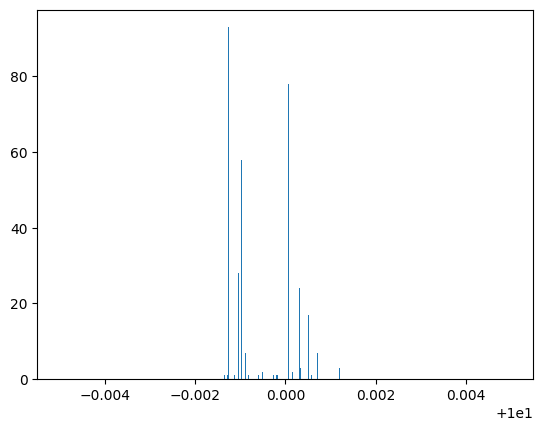

In [82]:
plt.hist(tres_lst, np.linspace (9.995, 10.005, 500));

In [ ]:
def minimizer(guess, event, function=Likelihood_3d):
    # Guess should be xyzt
    minimized = optimize.minimize(
        function, x0=guess, args=(event), method="Nelder-Mead", tol=1e-2
    )
    return minimized

In [ ]:
def Likelihood_3d_calculation(truth, Event) -> None:
    xary = np.linspace(truth[0] - 150, truth[0] + 150, 500)
    yary = np.linspace(truth[1] - 150, truth[1] + 150, 500)
    zary = np.linspace(truth[2] - 150, truth[2] + 150, 500)
    tary = np.linspace(truth[5] - 500, truth[5] + 500, 500)
    # phiary = np.linspace((truth[4] - 0.3), (truth[4] + 0.3), 500)
    # ThetaAry = np.linspace((truth[3] - 0.3), (truth[3] + 0.3), 500)
    phiary = np.linspace(0, np.pi, 500)
    ThetaAry = np.linspace(0, 2 * np.pi, 500)

    best_fit = np.array(
        [
            frame80["LLHFit_step5"].pos.x,
            frame80["LLHFit_step5"].pos.y,
            frame80["LLHFit_step5"].pos.z,
            frame80["LLHFit_step5"].dir.azimuth,
            frame80["LLHFit_step5"].dir.zenith,
            frame80["LLHFit_step5"].time,
        ]
    )

    xplot = []
    yplot = []
    zplot = []
    tplot = []
    phiplot = []
    thetaplot = []
    for i in range(len(xary)):
        xplot.append(
            Likelihood_3d(
                np.array([xary[i], truth[1], truth[2], truth[3], truth[4], truth[5]]),
                Event=Event,
            )
        )
        yplot.append(
            Likelihood_3d(
                np.array([truth[0], yary[i], truth[2], truth[3], truth[4], truth[5]]),
                Event=Event,
            )
        )
        zplot.append(
            Likelihood_3d(
                np.array([truth[0], truth[1], zary[i], truth[3], truth[4], truth[5]]),
                Event=Event,
            )
        )
        tplot.append(
            Likelihood_3d(
                np.array([truth[0], truth[1], truth[2], truth[3], truth[4], tary[i]]),
                Event=Event,
            )
        )
        phiplot.append(
            Likelihood_3d(
                np.array([truth[0], truth[1], truth[2], truth[3], phiary[i], truth[5]]),
                Event=Event,
            )
        )
        thetaplot.append(
            Likelihood_3d(
                np.array(
                    [truth[0], truth[1], truth[2], ThetaAry[i], truth[4], truth[5]]
                ),
                Event=Event,
            )
        )

    return [xplot, yplot, zplot, thetaplot, phiplot, tplot, best_fit]

In [ ]:
def likelihood_graphs(truth, data, filename: str):
    best_fit = data[-1]
    xary = np.linspace(truth[0] - 150, truth[0] + 150, 500)
    yary = np.linspace(truth[1] - 150, truth[1] + 150, 500)
    zary = np.linspace(truth[2] - 150, truth[2] + 150, 500)
    tary = np.linspace(truth[5] - 500, truth[5] + 500, 500)
    # phiary = np.linspace(
    #     (truth[4] - 0.3) * 360 / (2 * np.pi), (truth[4] + 0.3) * 360 / (2 * np.pi), 500
    # )
    # ThetaAry = np.linspace(
    #     (truth[3] - 0.3) * 360 / (2 * np.pi) - 10,
    #     (truth[3] + 0.3) * 360 / (2 * np.pi),
    #     500,
    # )
    phiary = np.linspace(0, 180, 500)
    ThetaAry = np.linspace(0, 360, 500)

    fig, axs = plt.subplots(2, 3, figsize=(12, 10))

    axs[0, 0].plot(xary, data[0])
    axs[0, 0].set_title("Likelihood Evolution in X")
    axs[0, 0].set_xlabel("X (m)")
    axs[0, 0].set_ylabel("-ln(L)")
    axs[0, 0].vlines(
        truth[0], min(data[0]), max(data[0]), label="Truth", colors="red", ls="--"
    )
    axs[0, 0].vlines(
        best_fit[0], min(data[0]), max(data[0]), label = "Best Fit", colors = "orange", ls = "--"
    )
    axs[0, 0].grid()
    # axs[0, 0].set_ylim(min(data[0]) - 10, min(data[0]) + 50)
    # axs[0, 0].set_xlim(truth[0] - 10, truth[0] + 10)
    # #axs[0,0].set_yscale('log')
    axs[0, 0].legend()

    axs[0, 1].plot(yary, data[1])
    axs[0, 1].set_title("Likelihood Evolution in Y")
    axs[0, 1].set_xlabel("Y (m)")
    axs[0, 1].set_ylabel("-ln(L)")
    axs[0, 1].grid()
    # axs[0, 1].set_ylim(min(data[1]) - 10, min(data[1]) + 70)
    # axs[0, 1].set_xlim(truth[1] - 10, truth[1] + 10)
    # #axs[0,1].set_yscale('log')
    axs[0, 1].vlines(
        truth[1], min(data[1]), max(data[1]), label="Truth", colors="red", ls="--"
    )
    axs[0, 1].vlines(
        best_fit[1], min(data[1]), max(data[1]), label = "Best Fit", colors = "orange", ls = "--"
    )
    axs[0, 1].legend()

    axs[1, 0].plot(zary, data[2])
    axs[1, 0].set_title("Likelihood Evolution in Z")
    axs[1, 0].set_xlabel("Z (m)")
    axs[1, 0].set_ylabel("-ln(L)")
    # axs[1, 0].set_ylim(min(data[2]) - 10, min(data[2]) + 50)
    # axs[1, 0].set_xlim(truth[2] - 10, truth[2] + 10)
    # #axs[1,0].set_yscale('log')
    axs[1, 0].vlines(
        truth[2], min(data[2]), max(data[2]), label="Truth", colors="red", ls="--"
    )
    axs[1, 0].vlines(
        best_fit[2], min(data[2]), max(data[2]), label = "Best Fit", colors = "orange", ls = "--"
    )
    axs[1, 0].grid()
    axs[1, 0].legend()

    axs[1, 1].plot(tary, data[5])
    axs[1, 1].set_title("Likelihood Evolution in t")
    axs[1, 1].set_xlabel("t (ns)")
    axs[1, 1].set_ylabel("-ln(L)")
    # axs[1, 1].set_xlim(truth[5] - 10, truth[5] + 10)
    # axs[1, 1].set_ylim(min(data[5]) - 50, min(data[5]) + 100)
    # #axs[1,1].set_yscale('log')
    axs[1, 1].vlines(
        truth[5], min(data[5]), max(data[5]), label="Truth", colors="red", ls="--"
    )
    axs[1, 1].vlines(
        best_fit[5], min(data[5]), max(data[5]), label = "Best Fit", colors = "orange", ls = "--"
    )
    axs[1, 1].grid()
    axs[1, 1].legend()

    axs[1, 2].plot(ThetaAry, data[3])
    axs[1, 2].set_title("Likelihood Evolution in Azimuth")
    axs[1, 2].set_xlabel("Azimuth (deg)")
    axs[1, 2].set_ylabel("-ln(L)")
    axs[1, 2].vlines(
        truth[3] * 360 / (2 * np.pi),
        min(data[3]),
        max(data[3]),
        label="Truth",
        colors="red",
        ls="--",
    )
    axs[1, 2].vlines(
        best_fit[3]*360 / (2*np.pi), min(data[3]), max(data[3]), label = "Best Fit", colors = "orange", ls = "--"
    )
    axs[1, 2].grid()
    # axs[1, 2].set_ylim(min(data[3]) - 10, min(data[3]) + 40)
    # axs[1, 2].set_xlim(
    #     truth[3] * 360 / (2 * np.pi) - 0.3 * 360 / (2 * np.pi),
    #     truth[3] * 360 / (2 * np.pi) + 0.3 * 360 / (2 * np.pi),
    # )
    # axs[1,2].set_yscale('log')
    axs[1, 2].legend()

    axs[0, 2].plot(phiary, data[4])
    axs[0, 2].set_title("Likelihood Evolution in Zenith")
    axs[0, 2].set_xlabel("Zenith (deg)")
    axs[0, 2].set_ylabel("-ln(L)")
    axs[0, 2].vlines(
        truth[4] * 360 / (2 * np.pi),
        min(data[4]),
        max(data[4]),
        label="Truth",
        colors="red",
        ls="--",
    )
    axs[0, 2].vlines(
        best_fit[4]*360 / (2*np.pi), min(data[4]), max(data[4]), label = "Best Fit", colors = "orange", ls = "--"
    )
    axs[0, 2].grid()
    # axs[0, 2].set_ylim(min(data[4]) - 10, min(data[4]) + 40)
    # axs[0, 2].set_xlim(
    #     truth[4] * 360 / (2 * np.pi) - 0.05 * 360 / (2 * np.pi),
    #     truth[4] * 360 / (2 * np.pi) + 0.05 * 360 / (2 * np.pi),
    # )
    # # axs[0,2].set_yscale('log')
    axs[0, 2].legend()

    fig.tight_layout()
    fig.savefig(f"../plots/{filename}.png")

In [ ]:
truth = np.array(
        [
            frame80["MCTruth"].pos.x,
            frame80["MCTruth"].pos.y,
            frame80["MCTruth"].pos.z,
            frame80["MCTruth"].dir.azimuth,
            frame80["MCTruth"].dir.zenith,
            frame80["MCTruth"].time,
        ]
    )
likelihood_data = Likelihood_3d_calculation(truth, EventDataLLHFit)

In [ ]:
best_fit = np.array(
        [
            frame80["LLHFit_step5"].pos.x,
            frame80["LLHFit_step5"].pos.y,
            frame80["LLHFit_step5"].pos.z,
            frame80["LLHFit_step5"].dir.azimuth,
            frame80["LLHFit_step5"].dir.zenith,
            frame80["LLHFit_step5"].time,
        ]
    )

In [ ]:
truth

array([630.77251293, 320.95764976, -83.63134648,   1.29878052,
         1.66787762,   0.        ])

In [ ]:
best_fit



array([630.49247256, 321.04956187, -83.5506991 ,   1.40049086,
         1.61989458,  -1.06219645])

In [ ]:
minimizer(np.array([383.862,517.832,377.6, 0.269028, 1.67479, 0]), EventData7)

NameError: name 'EventData7' is not defined

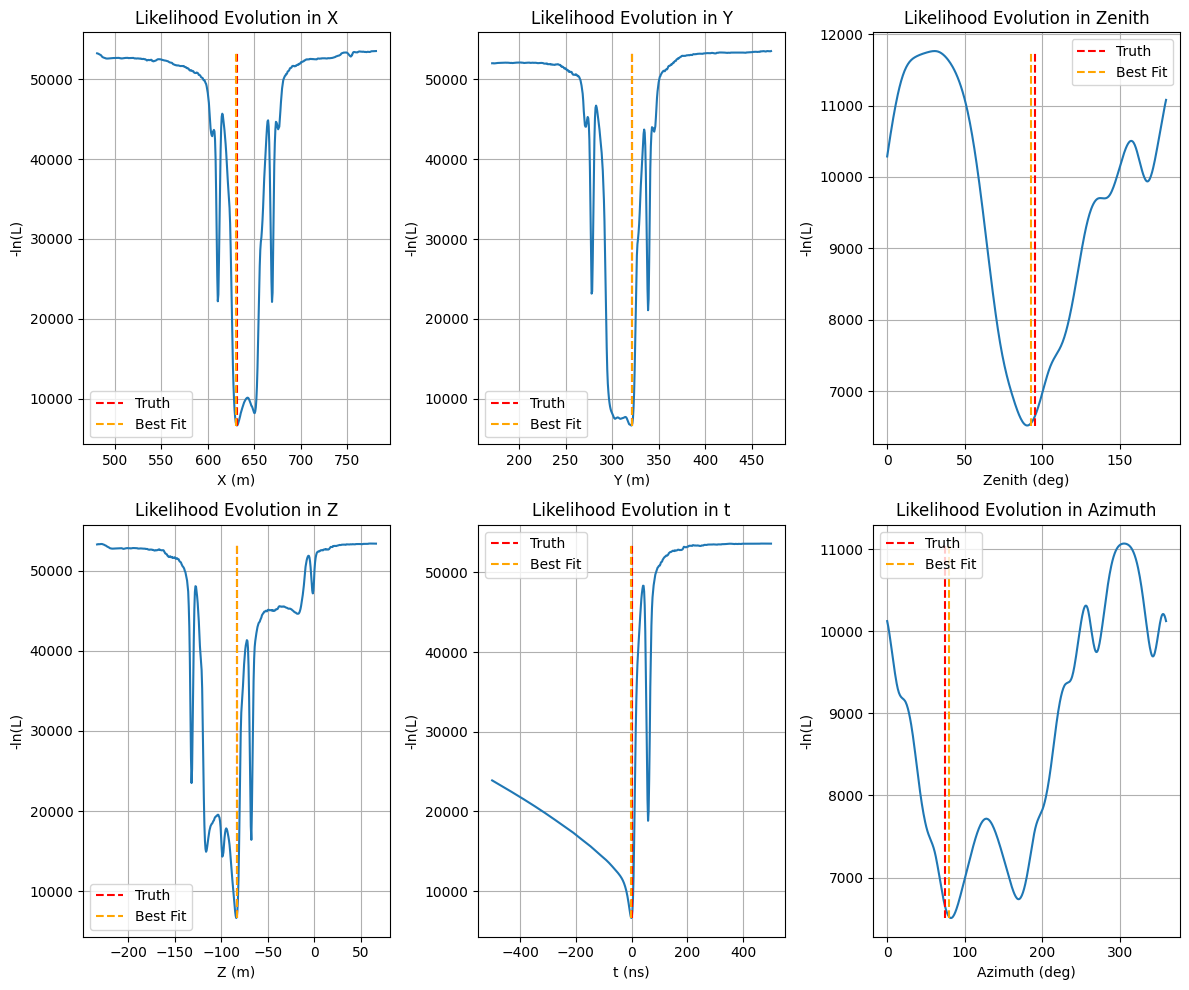

In [ ]:
likelihood_graphs(truth, likelihood_data, 'likelihood_evo_mmsreco')
## Check if scale factor exists for scipy

In [ ]:
def minimizer(guess, event, function=Likelihood_3d):
    # Guess should be xyzt
    minimized = optimize.minimize(function, 
                                  x0=guess,
                                  args=(event),  
                                  method='Nelder-Mead', 
                                  tol=1e-3)
    return minimized

In [ ]:
minimizer(np.array([2.86453,216.537,254.435, 5.03732, 1.12255, 0]), EventData1)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 33260.68909716606
             x: [ 2.787e+00  2.173e+02  2.551e+02  4.981e+00  9.819e-01
                 -2.515e-04]
           nit: 155
          nfev: 252
 final_simplex: (array([[ 2.787e+00,  2.173e+02, ...,  9.819e-01,
                        -2.515e-04],
                       [ 2.787e+00,  2.173e+02, ...,  9.819e-01,
                        -2.512e-04],
                       ...,
                       [ 2.786e+00,  2.173e+02, ...,  9.819e-01,
                        -2.511e-04],
                       [ 2.787e+00,  2.173e+02, ...,  9.820e-01,
                        -2.548e-04]]), array([ 3.326e+04,  3.326e+04,  3.326e+04,  3.326e+04,
                        3.326e+04,  3.326e+04,  3.326e+04]))

In [ ]:
print(2*(Likelihood_3d(np.array([2.86453,216.537,254.435, 5.03732, 1.12255, 0]), EventData1) - Likelihood_3d(np.array([3.420e+00, 2.155e+02, 2.549e+02, 5.367e+00, 1.146e+00, 3.699e-04]), EventData1)))


-4972.942487001419


In [ ]:
tgrid = np.linspace(min(splinefit_3d.knots[-1]), max(splinefit_3d.knots[-1]), 1000)
dist_for_pdf = 20.0
phiE_for_pdf = 0.3
pdf = np.exp(splinefit_3d.evaluate_simple([dist_for_pdf, phiE_for_pdf, tgrid]))


In [ ]:
space_angle_ary = np.array([])
energy_ary = np.array([])
for i in range(501):
    if i < 10:
        runnumber = '00' + str(i)
    elif i < 100:
        runnumber = '0' + str(i)
    else:
        runnumber = str(i)
    if os.path.isfile(f'/mnt/scratch/dillonb5/resolutions_80str/resolution_{runnumber}.npy'):
        #print(runnumber)
        ary = np.load(f'/mnt/scratch/dillonb5/resolutions_80str/resolution_{runnumber}.npy')
    
        if ary.shape == (0,):
            continue
       

        # zenith_ary = np.concatenate((zenith_ary, ary[:,0]))
        # azimuth_ary = np.concatenate((azimuth_ary, ary[:,1]))
        space_angle_ary = np.concatenate((space_angle_ary, ary[:,0]))
        energy_ary = np.concatenate((energy_ary, ary[:,1]))


In [ ]:
len(space_angle_ary)

14566

In [ ]:
space_angle_ary = space_angle_ary*360/(2*np.pi)

In [ ]:
space_angle_ary

array([42.2152582 ,  7.83137182, 38.40023154, ...,  1.57285607,
       10.79123599, 31.01457916])

In [ ]:
count=0
for val in space_angle_ary:
    if not np.isnan(val):
        count+=1
print(count)

14566


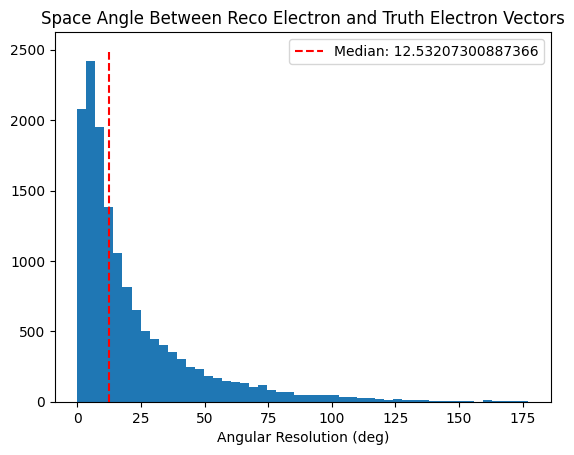

In [ ]:
plt.hist(space_angle_ary, 50)
plt.vlines(np.median(space_angle_ary), 0, 2500, colors='red', ls='--', label=f'Median: {np.median(space_angle_ary)}')
plt.title('Space Angle Between Reco Electron and Truth Electron Vectors')
plt.xlabel('Angular Resolution (deg)')
plt.legend()
plt.savefig(
    '/mnt/home/dillonb5/cascades/plots/angular_res_v1.png'
)

In [ ]:
hist, edges = np.histogram(energy_ary, bins=np.logspace(2, 6, 17))
print(hist)
print(edges)

[4487 3070 2144 1362  989  682  502  356  272  186  135  112   86   89
   64   30]
[1.00000000e+02 1.77827941e+02 3.16227766e+02 5.62341325e+02
 1.00000000e+03 1.77827941e+03 3.16227766e+03 5.62341325e+03
 1.00000000e+04 1.77827941e+04 3.16227766e+04 5.62341325e+04
 1.00000000e+05 1.77827941e+05 3.16227766e+05 5.62341325e+05
 1.00000000e+06]


In [ ]:
def truncate(f, n):
        '''Truncates/pads a float f to n decimal places without rounding'''
        s = '{}'.format(f)
        if 'e' in s or 'E' in s:
                return '{0:.{1}f}'.format(f, n)
        i, p, d = s.partition('.')
        return '.'.join([i, (d+'0'*n)[:n]])

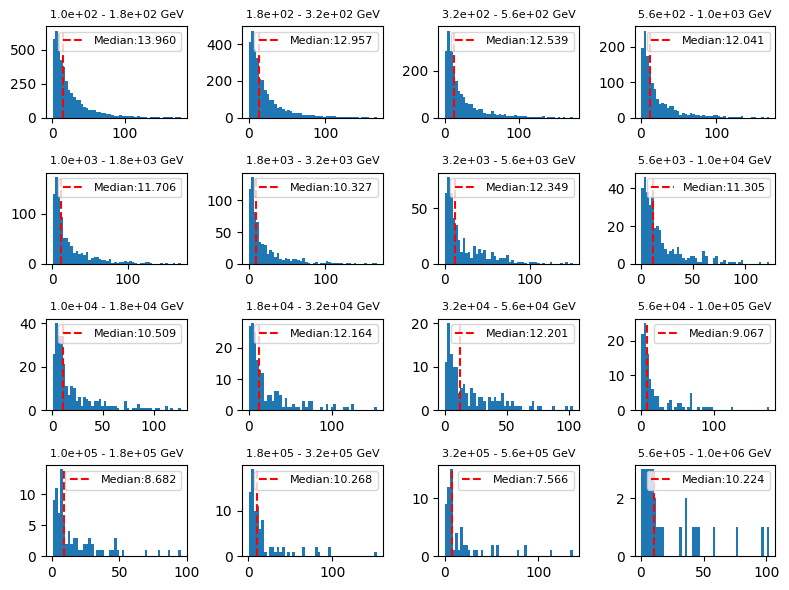

In [ ]:
fig, axs = plt.subplots(4,4, figsize = (8,6))
ct = 0
for i in range(len(axs)):
    for j in range(len(axs[i])):
        bin_mask = (energy_ary >= edges[ct]) & (energy_ary < edges[ct + 1])
        bin_res = space_angle_ary[bin_mask]
        counts, _ = np.histogram(bin_res, bins=50)
        axs[i,j].hist(bin_res, bins=50)
        axs[i,j].set_title(f'{edges[ct]:.1e} - {edges[ct+1]:.1e} GeV', fontsize=8)
        axs[i,j].vlines(np.median(bin_res), 0, max(counts), colors='red', ls='--', label=f'Median:{truncate(np.median(bin_res),3)}')
        #axs[i,j].set_xlabel('Angular Resolution (deg)', fontsize=8)
        axs[i,j].legend(fontsize=8)
        
        ct += 1

fig.tight_layout()
plt.savefig('/mnt/home/dillonb5/cascades/plots/angular_res_energy_binned.png')



In [ ]:
splinefit_3d.extents

((2.0920000317428116, 279.13374889976023),
 (0.0, 3.141592653589793),
 (-30.726762008826114, 1627.6756954685331))

In [ ]:
def cdf(coords, Event):
    t = np.linspace(splinefit_3d.extents[2][0], splinefit_3d.extents[2][1], 2500)
    pvalues = []
    for event in Event:
        dr = displacement_magnitude(coords[0:3], np.array(event[0:3]))
        diff = coords[0:3] - np.array(event[0:3])

        Ex = np.sin(coords[4])*np.cos(coords[3])
        Ey = np.sin(coords[4])*np.sin(coords[3])
        Ez = np.cos(coords[4])


        # Calculate angle between electron travel vector and displacement vector
        Eangle = np.array([Ex, Ey, Ez])
        Ephi = np.arccos(np.dot(diff, Eangle) / dr)
        
        
        #dt = abs(coords[3] - event[3]) - (1.34*dr/c * 1e9)
        #pdf = evalPdf(splinefit_3d, dr, Ephi, t)
        pdf = np.exp(splinefit_3d.evaluate_simple([dr, Ephi, t]))
        cdf = np.sum(pdf[np.searchsorted(t, event[-1]):])/np.sum(pdf)
        pvalues.append(cdf)

    plt.hist(pvalues, bins=np.linspace(min(pvalues),max(pvalues),50))
    plt.xlabel('CDF Value')
    plt.ylabel('Hits')
    plt.title('3D CDF Distribution')

In [ ]:
def cdf_color_plt(coords, Event):
    pvalues = []
    for event in Event:
        dr = displacement_magnitude(coords[0:3], np.array(event[0:3]))
        diff = coords[0:3] - np.array(event[0:3])

        Ex = np.sin(coords[4])*np.cos(coords[3])
        Ey = np.sin(coords[4])*np.sin(coords[3])
        Ez = np.cos(coords[4])


        # Calculate angle between electron travel vector and displacement vector
        Eangle = np.array([Ex, Ey, Ez])
        Ephi = np.arccos(np.dot(diff, Eangle) / dr)
        
        
        #dt = abs(coords[3] - event[3]) - (1.34*dr/c * 1e9)
        pdf = np.exp(splinefit_3d.evaluate_simple([dr,Ephi, t]))
        cdf = np.sum(pdf[np.searchsorted(t, event[-1]):])/np.sum(pdf)
        pvalues.append((cdf, Ephi))
    twoDary = np.array(pvalues)
    #print(twoDary)
    hist, edges = np.histogramdd(twoDary, bins=20)
    print(twoDary)
    
    fig, ax = plt.subplots()
    plot = ax.imshow(
        hist.T,                    # Transpose so axis 0 = x, axis 1 = y
        origin='lower',            # Put (0,0) at bottom-left, not top-left
        aspect='auto',
        norm=LogNorm(vmin=1, vmax=hist.max()),             # Don't force square pixels
        extent=[                   # Map pixel coords to data coords
            edges[0][0], edges[0][-1],   # x: cdf axis range
            edges[1][0], edges[1][-1]    # y: dr axis range
        ]
    )
    cbar = ax.figure.colorbar(plot, ax=ax, )
    cbar.ax.set_ylabel('Bin counts', rotation=-90, va="bottom")
    ax.set_xlabel('CDF')
    ax.set_ylabel('Emission Angle')
    plt.tight_layout()
    plt.show()

In [ ]:
#cdf_color_plt(np.array([632.878,-456.534,-261.346, 0.938481, 2.22391,0]), EventData2)

In [ ]:
i = 0
for frame in dataio.I3File('/mnt/scratch/dillonb5/sampled_data_3d/new_030.i3.zst'):
    i += 1
    if i == 4:
        frame4 = frame

EventDataSampled = datacollect(frame4)

In [ ]:
print(frame4['I3MCTree'][1])

[ I3Particle MajorID : 14046764660786732053
             MinorID : 6574
              Zenith : 0.959005
             Azimuth : 5.38552
                   X : 408.884
                   Y : -107.673
                   Z : -215.372
                Time : 0
              Energy : 54783.3
               Speed : 0.299792
              Length : nan
                Type : EPlus
        PDG encoding : -11
               Shape : Cascade
              Status : NotSet
            Location : InIce
]


In [ ]:
len(EventDataSampled)

1069

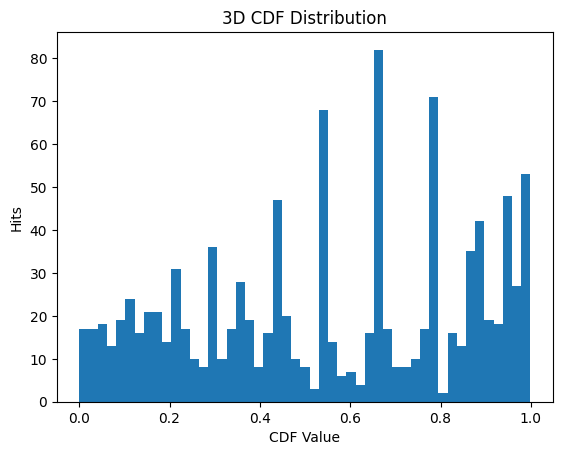

In [ ]:
cdf(np.array([-125.545, 719.033, -311.44, 2.31525, 1.0098]), EventDataSampled)

In [ ]:
best_fit = minimizer(np.array([632.878,-456.534,-261.346, 0.938481, 2.22391,0]), EventData2)
cdf(best_fit['x'], EventData2)

KeyboardInterrupt: 

In [ ]:
def sample_dt(dr, dphi):
    pvalues = []
    spline=splinefit_3d 
    t = np.linspace(spline.extents[-1][0], spline.extents[-1][1], 2000)
    pdf = evalPdf(spline, dr, dphi, t)
    for dt in t:
        cdf = np.sum(pdf[:np.searchsorted(t, dt)])/np.sum(pdf)
        pvalues.append(cdf)
    return t, pvalues

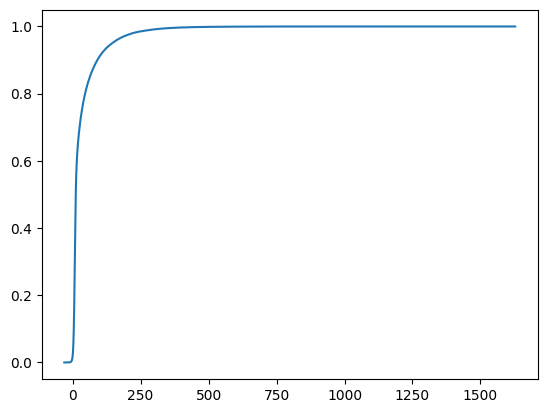

In [ ]:
t, p = sample_dt(100, 0)
plt.plot(t, p)

In [ ]:
ary1 = np.array([1,2,3])
ary2 = np.array([4,5,6])
stacked = np.column_stack([ary1, ary2])
print(stacked)
for i in range(len(stacked)):
    print(stacked[i,1])

[[1 4]
 [2 5]
 [3 6]]
4
5
6
